# MassSpecGym S4-based retrieval candidates — final analysis

Analysis of the **final** retrieval candidate sets after the three-step
augmentation pipeline (expmisc004):

  1. **S4** — 200M raw samples from the MSG-train-only fine-tuned S4 generator,
     standardised via `massspecgym.utils.rdkit_canonical_smiles`, deduped by
     2D-InChIKey. Produces a leakage-clean pool (144 / 64.2M overlap with MSG
     val+test).
  2. **PubChem v1.5 fallback** — for queries whose S4 bucket has fewer than 8
     candidates, append PubChem-v1.5 candidates whose 2D-InChIKey is not already
     present, up to the 1024 cap.
  3. **Molpher RerouteBond fill** (formula only) — for the remaining queries
     still at len<8 after step 2, run Molpher's formula-preserving
     `RerouteBond` operator (10k attempts/query), select diverse morphs via
     greedy farthest-first Tanimoto, append up to 1024 cap.

**Files analysed:**
- Formula final: `MassSpecGym/data/MassSpecGym_S4plusPCplusMol_retrieval_candidates_formula.json` (968 MB)
- Mass final: `MassSpecGym/data/MassSpecGym_S4plusPC_retrieval_candidates_mass.json` (1.28 GB) — Molpher not applied (already at 0% trivial after step 2).

**Per-step intermediate files (used to attribute candidates to their source):**
- `MassSpecGym_S4_retrieval_candidates_{formula,mass}.json` (pure S4)
- `MassSpecGym_S4plusPC_retrieval_candidates_{formula,mass}.json` (S4 + PubChem)

In [1]:
import json
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolDescriptors, AllChem
from rdkit.DataStructs import BulkTanimotoSimilarity
from rdkit.Chem.Draw import MolsToGridImage
from rdkit.Chem.Scaffolds import MurckoScaffold
from IPython.display import Image as _IPImage, display
RDLogger.DisableLog('rdApp.*')

S4_DIR = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/experiments/data_builds/MassSpecGym_S4')
FIG_DIR = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/notebooks/massspecgym_in_the_wild/figures_final_candidates')
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path('/pfs/lustrep2/scratch/project_465002061/rbushuie/DreaMS-Mol_dev/MassSpecGym/data')

S4F_JSON          = DATA_DIR / 'MassSpecGym_S4_retrieval_candidates_formula.json'
S4M_JSON          = DATA_DIR / 'MassSpecGym_S4_retrieval_candidates_mass.json'
S4PC_F_JSON       = DATA_DIR / 'MassSpecGym_S4plusPC_retrieval_candidates_formula.json'
S4PC_M_JSON       = DATA_DIR / 'MassSpecGym_S4plusPC_retrieval_candidates_mass.json'
S4PCMOL_F_JSON    = DATA_DIR / 'MassSpecGym_S4plusPCplusMol_retrieval_candidates_formula.json'
PUBCHEM_F_V15_JSON = DATA_DIR / 'MassSpecGym1.5_retrieval_candidates_formula.json'
PUBCHEM_M_V15_JSON = DATA_DIR / 'MassSpecGym1.5_retrieval_candidates_mass.json'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Arial', 'Helvetica'],
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 10,
    'legend.fontsize': 8, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True,
    'grid.color': '#DDDDDD', 'grid.linewidth': 0.5, 'grid.alpha': 0.8,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

S4_COLOR      = '#D95F5F'   # red — S4
PUBCHEM_COLOR = '#6A889F'   # steel blue — PubChem
MOLPHER_COLOR = '#7CB342'   # green — Molpher
POOL_COLOR    = '#F2D249'   # gold
FINAL_COLOR   = '#9B59B6'   # purple — final


def _despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', direction='out', length=3)


def _save(fig, name):
    fig.savefig(FIG_DIR / f'{name}.png')
    fig.savefig(FIG_DIR / f'{name}.svg')

## 1 — Step contribution: how many candidates came from each source

Decompose each final candidate list into (S4, PubChem, Molpher) contributions by
comparing the three formula JSONs (and the two mass JSONs). For each query:

  - **S4 contribution** = candidates in the pure-S4 JSON, excluding the query.
  - **PubChem contribution** = candidates that appear in the S4+PC JSON but
    not in the pure-S4 JSON.
  - **Molpher contribution** (formula only) = candidates in S4+PC+Mol that
    are not in S4+PC.

In [2]:
t0 = time.perf_counter()
with S4F_JSON.open() as f:       s4_f = json.load(f)
with S4PC_F_JSON.open() as f:    s4pc_f = json.load(f)
with S4PCMOL_F_JSON.open() as f: s4pcmol_f = json.load(f)
with S4M_JSON.open() as f:       s4_m = json.load(f)
with S4PC_M_JSON.open() as f:    s4pc_m = json.load(f)
print(f'loaded 5 JSONs in {time.perf_counter()-t0:.1f}s')

def _attribute_three_step(q, s4_d, pc_d, final_d):
    s4_set = set(s4_d[q][1:]) if q in s4_d else set()  # exclude query at idx 0
    pc_set = set(pc_d[q][1:]) if q in pc_d else set()
    final_set = set(final_d[q][1:]) if q in final_d else set()
    n_s4  = len(s4_set & final_set)
    n_pc  = len((pc_set - s4_set) & final_set)
    n_mol = len(final_set - s4_set - pc_set)
    return n_s4, n_pc, n_mol

def _attribute_two_step(q, s4_d, pc_d):
    s4_set = set(s4_d[q][1:]) if q in s4_d else set()
    pc_set = set(pc_d[q][1:]) if q in pc_d else set()
    n_s4 = len(s4_set & pc_set)
    n_pc = len(pc_set - s4_set)
    return n_s4, n_pc

# Formula attribution.
rows_f = []
for q in s4pcmol_f:
    n_s4, n_pc, n_mol = _attribute_three_step(q, s4_f, s4pc_f, s4pcmol_f)
    rows_f.append((q, n_s4, n_pc, n_mol, n_s4 + n_pc + n_mol + 1))
df_attr_f = pd.DataFrame(rows_f, columns=['query', 'n_s4', 'n_pc', 'n_mol', 'total']).set_index('query')

# Mass attribution.
rows_m = []
for q in s4pc_m:
    n_s4, n_pc = _attribute_two_step(q, s4_m, s4pc_m)
    rows_m.append((q, n_s4, n_pc, n_s4 + n_pc + 1))
df_attr_m = pd.DataFrame(rows_m, columns=['query', 'n_s4', 'n_pc', 'total']).set_index('query')

print('FORMULA attribution:')
print(f'  n_queries: {len(df_attr_f):,}')
print(f'  queries with ≥1 S4 candidate:      {int((df_attr_f["n_s4"]  > 0).sum()):,} ({(df_attr_f["n_s4"]  > 0).mean()*100:.2f}%)')
print(f'  queries with ≥1 PubChem candidate: {int((df_attr_f["n_pc"]  > 0).sum()):,} ({(df_attr_f["n_pc"]  > 0).mean()*100:.2f}%)')
print(f'  queries with ≥1 Molpher candidate: {int((df_attr_f["n_mol"] > 0).sum()):,} ({(df_attr_f["n_mol"] > 0).mean()*100:.2f}%)')
print(f'  total cands per source: S4={int(df_attr_f["n_s4"].sum()):,}  PC={int(df_attr_f["n_pc"].sum()):,}  Mol={int(df_attr_f["n_mol"].sum()):,}')
print()
print('MASS attribution:')
print(f'  n_queries: {len(df_attr_m):,}')
print(f'  queries with ≥1 S4 candidate:      {int((df_attr_m["n_s4"] > 0).sum()):,} ({(df_attr_m["n_s4"] > 0).mean()*100:.2f}%)')
print(f'  queries with ≥1 PubChem candidate: {int((df_attr_m["n_pc"] > 0).sum()):,} ({(df_attr_m["n_pc"] > 0).mean()*100:.2f}%)')
print(f'  total cands per source: S4={int(df_attr_m["n_s4"].sum()):,}  PC={int(df_attr_m["n_pc"].sum()):,}')

loaded 5 JSONs in 20.5s


FORMULA attribution:
  n_queries: 28,918
  queries with ≥1 S4 candidate:      28,043 (96.97%)
  queries with ≥1 PubChem candidate: 1,550 (5.36%)
  queries with ≥1 Molpher candidate: 448 (1.55%)
  total cands per source: S4=19,348,920  PC=42,789  Mol=325,250

MASS attribution:
  n_queries: 28,918
  queries with ≥1 S4 candidate:      28,782 (99.53%)
  queries with ≥1 PubChem candidate: 463 (1.60%)
  total cands per source: S4=25,671,026  PC=83,345


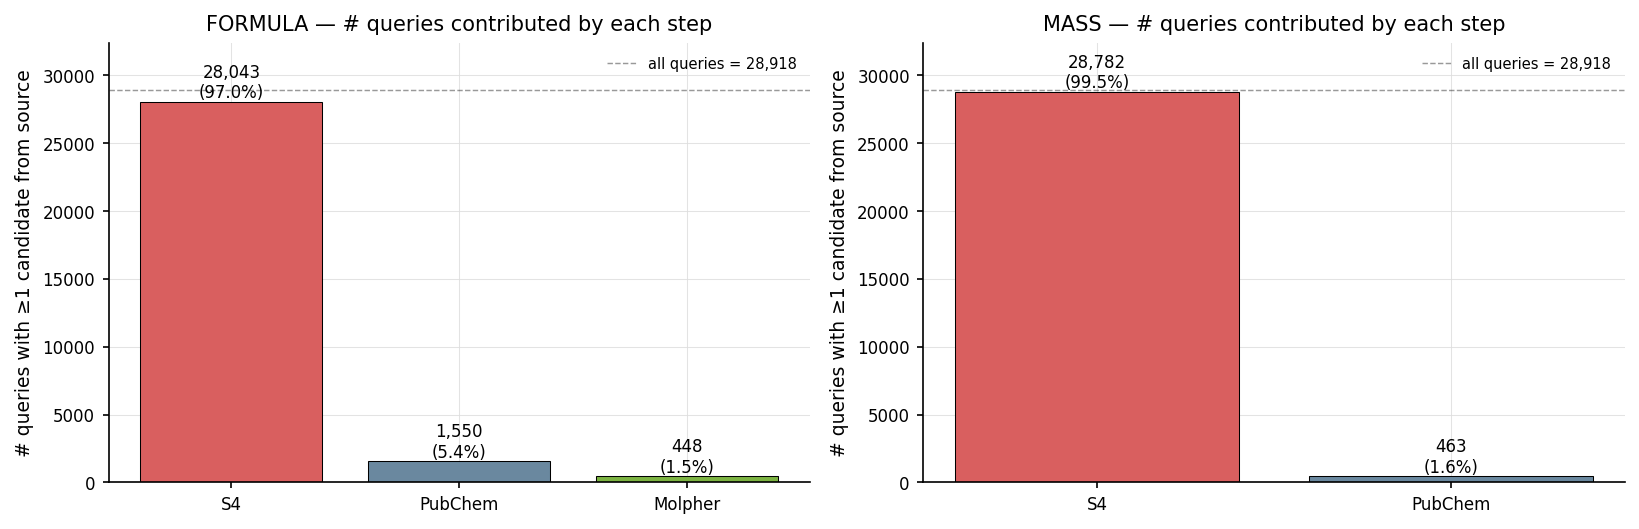

In [3]:
# Bar plot: how many queries got ≥1 candidate from each source.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

# Formula.
n_q_f = len(df_attr_f)
counts_f = [
    int((df_attr_f['n_s4']  > 0).sum()),
    int((df_attr_f['n_pc']  > 0).sum()),
    int((df_attr_f['n_mol'] > 0).sum()),
]
labels_f = ['S4', 'PubChem', 'Molpher']
colors_f = [S4_COLOR, PUBCHEM_COLOR, MOLPHER_COLOR]
ax = axes[0]
bars = ax.bar(labels_f, counts_f, color=colors_f, edgecolor='black', linewidth=0.5)
for b, c in zip(bars, counts_f):
    ax.text(b.get_x() + b.get_width()/2, c, f'{c:,}\n({c/n_q_f*100:.1f}%)',
            ha='center', va='bottom', fontsize=8)
ax.axhline(n_q_f, color='black', linestyle='--', linewidth=0.7, alpha=0.4, label=f'all queries = {n_q_f:,}')
ax.set_ylim(0, n_q_f * 1.12)
ax.set_ylabel('# queries with ≥1 candidate from source')
ax.set_title('FORMULA — # queries contributed by each step')
ax.legend(frameon=False, fontsize=7)
_despine(ax)

# Mass.
n_q_m = len(df_attr_m)
counts_m = [
    int((df_attr_m['n_s4'] > 0).sum()),
    int((df_attr_m['n_pc'] > 0).sum()),
]
labels_m = ['S4', 'PubChem']
colors_m = [S4_COLOR, PUBCHEM_COLOR]
ax = axes[1]
bars = ax.bar(labels_m, counts_m, color=colors_m, edgecolor='black', linewidth=0.5)
for b, c in zip(bars, counts_m):
    ax.text(b.get_x() + b.get_width()/2, c, f'{c:,}\n({c/n_q_m*100:.1f}%)',
            ha='center', va='bottom', fontsize=8)
ax.axhline(n_q_m, color='black', linestyle='--', linewidth=0.7, alpha=0.4, label=f'all queries = {n_q_m:,}')
ax.set_ylim(0, n_q_m * 1.12)
ax.set_ylabel('# queries with ≥1 candidate from source')
ax.set_title('MASS — # queries contributed by each step')
ax.legend(frameon=False, fontsize=7)
_despine(ax)

fig.tight_layout()
_save(fig, 'step_contribution_queries')
plt.show()

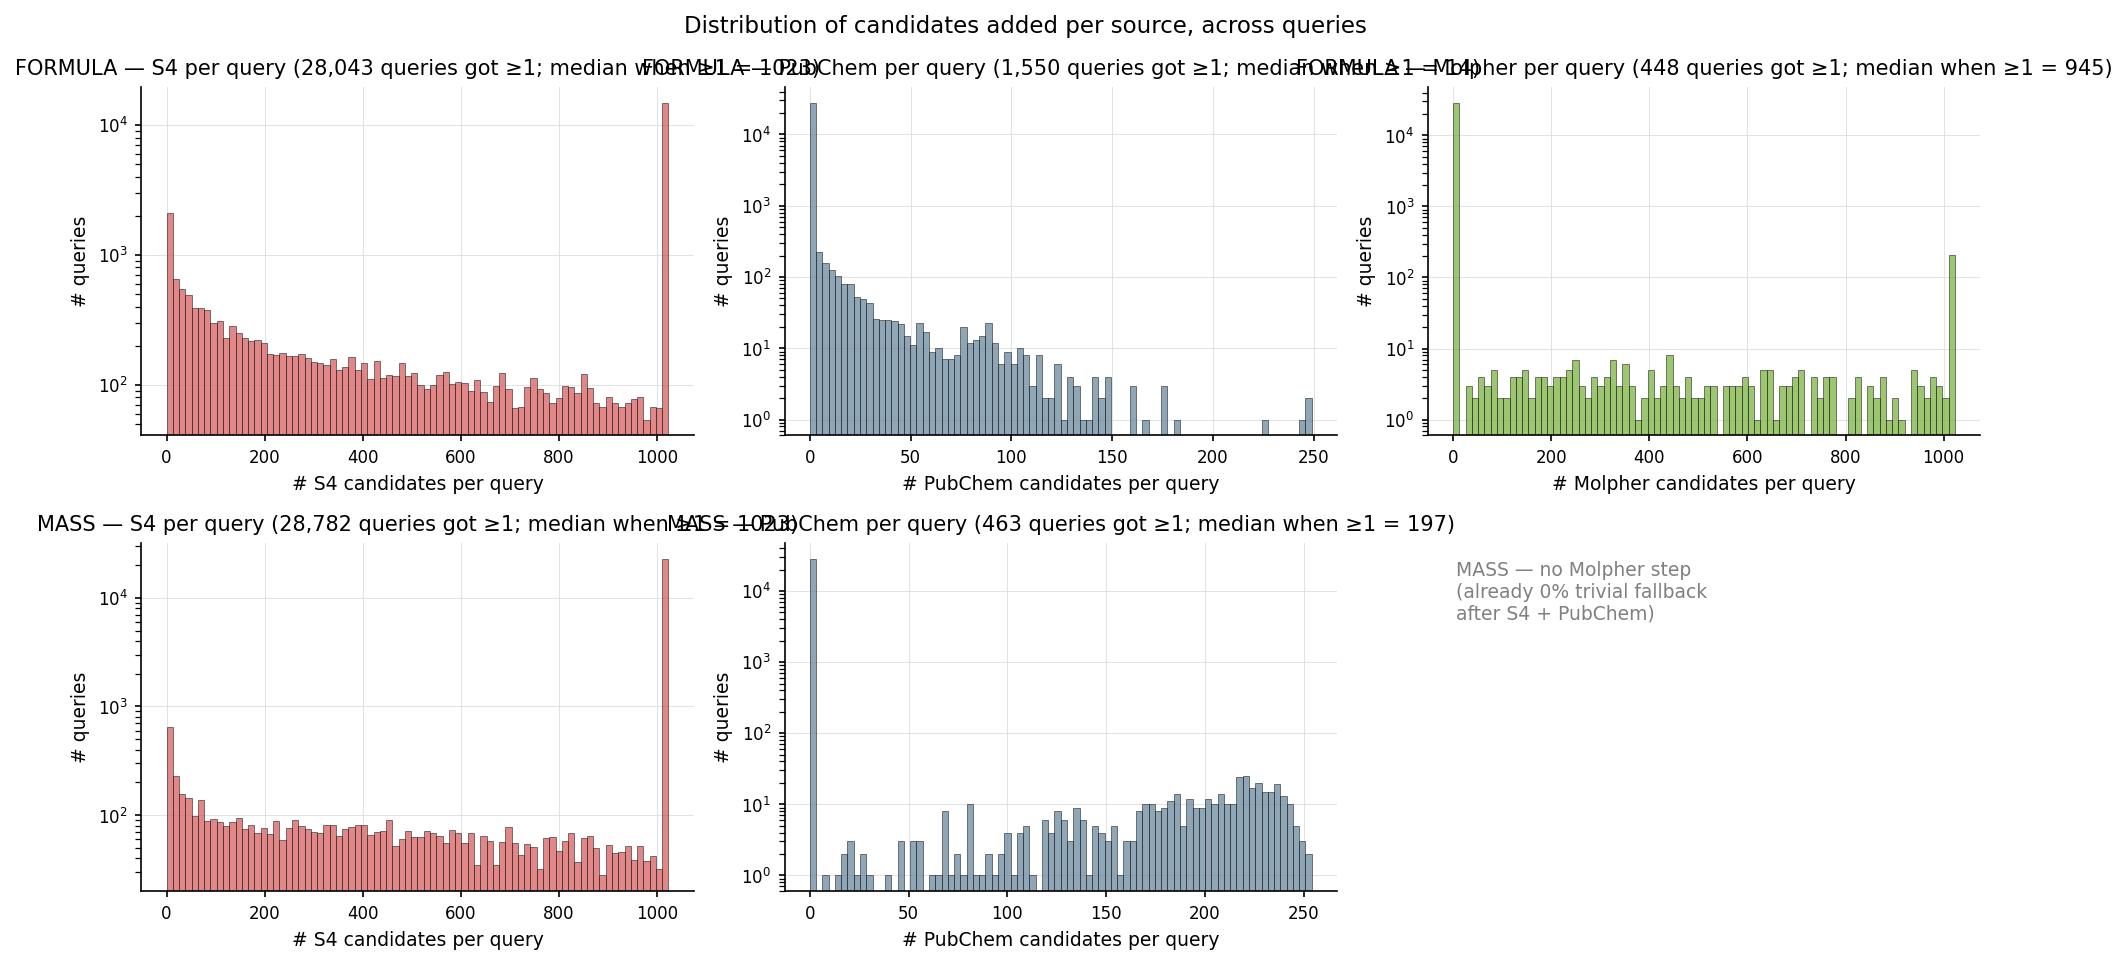

In [4]:
# Histograms: distribution of n_added per source across queries.
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))

# Top row: FORMULA — three sources.
for ax, col, color, label in zip(axes[0], ['n_s4', 'n_pc', 'n_mol'], [S4_COLOR, PUBCHEM_COLOR, MOLPHER_COLOR], ['S4', 'PubChem', 'Molpher']):
    vals = df_attr_f[col]
    # Use symlog if values span wide range.
    nz = vals[vals > 0]
    ax.hist(np.clip(vals, 0, 1024), bins=80, color=color, alpha=0.75, edgecolor='black', linewidth=0.3)
    ax.set_xlabel(f'# {label} candidates per query')
    ax.set_ylabel('# queries')
    ax.set_title(f'FORMULA — {label} per query ({int((vals > 0).sum()):,} queries got ≥1; median when ≥1 = {int(nz.median()) if len(nz) else 0})')
    ax.set_yscale('log')
    _despine(ax)

# Bottom row: MASS — two sources + an empty/info panel.
for ax, col, color, label in zip(axes[1][:2], ['n_s4', 'n_pc'], [S4_COLOR, PUBCHEM_COLOR], ['S4', 'PubChem']):
    vals = df_attr_m[col]
    nz = vals[vals > 0]
    ax.hist(np.clip(vals, 0, 1024), bins=80, color=color, alpha=0.75, edgecolor='black', linewidth=0.3)
    ax.set_xlabel(f'# {label} candidates per query')
    ax.set_ylabel('# queries')
    ax.set_title(f'MASS — {label} per query ({int((vals > 0).sum()):,} queries got ≥1; median when ≥1 = {int(nz.median()) if len(nz) else 0})')
    ax.set_yscale('log')
    _despine(ax)

# Empty panel.
axes[1][2].axis('off')
axes[1][2].text(0.05, 0.95, 'MASS — no Molpher step\n(already 0% trivial fallback\nafter S4 + PubChem)',
                transform=axes[1][2].transAxes, va='top', fontsize=9, color='gray')

fig.suptitle('Distribution of candidates added per source, across queries', fontsize=11)
fig.tight_layout()
_save(fig, 'step_contribution_distribution')
plt.show()

In [5]:
# Step contribution stats table.
rows = []
for label, df, n_total in [('FORMULA', df_attr_f, len(df_attr_f)), ('MASS', df_attr_m, len(df_attr_m))]:
    for src_col, src_name in [('n_s4', 'S4'), ('n_pc', 'PubChem')] + ([('n_mol', 'Molpher')] if 'n_mol' in df.columns else []):
        vals = df[src_col]
        nz = vals[vals > 0]
        rows.append({
            'variant': label, 'source': src_name,
            'queries_with_>=1': int((vals > 0).sum()),
            'queries_with_>=1_pct': float((vals > 0).mean() * 100),
            'total_cands_from_source': int(vals.sum()),
            'mean_per_query': float(vals.mean()),
            'mean_per_query_when_>0': float(nz.mean()) if len(nz) else 0.0,
            'median_per_query_when_>0': float(nz.median()) if len(nz) else 0.0,
        })
df_step = pd.DataFrame(rows)
display(df_step.round(2))

,variant,source,queries_with_>=1,queries_with_>=1_pct,total_cands_from_source,mean_per_query,mean_per_query_when_>0,median_per_query_when_>0
0,FORMULA,S4,28043,96.97,19348920,669.10,689.97,1023.0
1,FORMULA,PubChem,1550,5.36,42789,1.48,27.61,14.0
2,FORMULA,Molpher,448,1.55,325250,11.25,726.00,945.0
3,MASS,S4,28782,99.53,25671026,887.72,891.91,1023.0
4,MASS,PubChem,463,1.60,83345,2.88,180.01,197.0


## 1a — Sample validity (pure S4)

Pure-S4 generation diagnostics: what fraction of raw S4 strings parse via RDKit? Reported per temperature on a sub-sample of shards. Unchanged vs the previous notebook (same underlying pool).

In [6]:
shard_paths = sorted(S4_DIR.glob('samples/temp_*/shard_*.parquet'))
print(f'sample shards: {len(shard_paths)}')


def _temp_from(p):
    return float(p.parent.name.replace('temp_', ''))


N_PER_SHARD = 2000
rng = np.random.RandomState(0)
rows = []
for p in shard_paths:
    df = pd.read_parquet(p, columns=['smiles', 'log_likelihood', 'temperature'])
    samp = df.sample(n=min(N_PER_SHARD, len(df)), random_state=rng)
    rows.append({
        'temperature': _temp_from(p),
        'n_raw': len(df),
        'n_sampled': len(samp),
        'n_parse_sampled': int(samp['smiles'].map(lambda s: Chem.MolFromSmiles(s) is not None).sum()),
    })
df_validity = pd.DataFrame(rows).groupby('temperature').sum().reset_index()
df_validity['parse_rate'] = df_validity['n_parse_sampled'] / df_validity['n_sampled']
df_validity

sample shards: 1008


,temperature,n_raw,n_sampled,n_parse_sampled,parse_rate
0,0.7,66666672,672000,662956,0.986542
1,1.0,66666672,672000,641519,0.954641
2,1.2,66666672,672000,612955,0.912135


In [7]:
buckets = pd.read_parquet(S4_DIR / 'buckets.parquet')
n_pool = len(buckets)
n_raw_total = sum(pq.read_metadata(p).num_rows for p in shard_paths)
print(f'raw sampled: {n_raw_total:,}')
print(f'in pool (post-canon + dedup by 2D-InChIKey): {n_pool:,}')
print(f'overall pool/raw rate: {n_pool/n_raw_total*100:.2f}%')
print(f'unique formulas in pool: {buckets["formula"].nunique():,}')

raw sampled: 200,000,016
in pool (post-canon + dedup by 2D-InChIKey): 64,205,194
overall pool/raw rate: 32.10%


unique formulas in pool: 1,470,580


## 1b — Per-temperature S4 quality breakdown

This is the per-temperature characterisation of the underlying S4 generation that
feeds the final pool. Same as in the previous notebook.

In [8]:
TEMPS = [0.7, 1.0, 1.2]
N_RAW_PER_TEMP = 15000

per_temp_rows = []
for temp in TEMPS:
    shards_t = sorted(S4_DIR.glob(f'samples/temp_{temp:.2f}/shard_*.parquet'))
    n_raw_temp = sum(pq.read_metadata(p).num_rows for p in shards_t)
    rng = np.random.RandomState(int(temp * 100))
    take_shards = list(rng.choice(shards_t, size=min(5, len(shards_t)), replace=False))
    n_per_shard = max(1, N_RAW_PER_TEMP // 5)
    dfs = []
    for p in take_shards:
        df = pd.read_parquet(p, columns=['smiles', 'log_likelihood'])
        dfs.append(df.sample(n=min(n_per_shard, len(df)), random_state=rng))
    df_temp = pd.concat(dfs, ignore_index=True)

    mols = df_temp['smiles'].map(Chem.MolFromSmiles)
    parse_mask = mols.notna()
    valid = df_temp[parse_mask].reset_index(drop=True)
    valid_mols = mols[parse_mask].reset_index(drop=True)
    charges = valid_mols.map(Chem.GetFormalCharge)
    heavy = valid_mols.map(lambda m: m.GetNumHeavyAtoms())
    iks = valid_mols.map(lambda m: Chem.MolToInchiKey(m)[:14] if m is not None else None)
    n_pool_temp = int((buckets['temperature'].round(2) == round(temp, 2)).sum())

    per_temp_rows.append({
        'temperature': temp,
        'n_raw': n_raw_temp,
        'n_pool_attributed': n_pool_temp,
        'pool_yield': n_pool_temp / n_raw_temp,
        'parse_rate': float(parse_mask.mean()),
        'frac_disconnected': float(valid['smiles'].str.contains(r'\.').mean()) if len(valid) else float('nan'),
        'frac_nonzero_charge': float((charges != 0).mean()) if len(charges) else float('nan'),
        'mean_heavy_atoms': float(heavy.mean()) if len(heavy) else float('nan'),
        'mean_log_likelihood': float(valid['log_likelihood'].mean()) if len(valid) else float('nan'),
        'unique_ik2d_frac_in_sample': iks.nunique() / max(1, len(iks)),
    })
df_per_temp = pd.DataFrame(per_temp_rows).set_index('temperature')
display(df_per_temp.round(4))

,n_raw,n_pool_attributed,pool_yield,parse_rate,frac_disconnected,frac_nonzero_charge,mean_heavy_atoms,mean_log_likelihood,unique_ik2d_frac_in_sample
temperature,,,,,,,,,
0.7,66666672,8330299,0.1250,0.9876,0.0,0.0005,27.8055,-0.3117,0.6686
1.0,66666672,23751373,0.3563,0.9551,0.0,0.0013,25.2546,-0.4384,0.9117
1.2,66666672,32123522,0.4819,0.9122,0.0,0.0042,24.3127,-0.5406,0.9638


## 2 — Diversity: novelty vs MSG splits + scaffold count + internal Tanimoto

Diversity diagnostics computed on the **pool** (pure S4 candidates) — same as the
previous notebook. The PubChem and Molpher additions are query-specific tail
candidates and don't change the bulk pool characteristics.

In [9]:
queries = pd.read_parquet(S4_DIR / 'extract_unique_mols.parquet')
print(f'MSG queries (all folds): {len(queries):,}')
print('fold counts:'); print(queries['fold'].value_counts())

msg_iks_all = set(queries['inchikey_2d'])
msg_iks_train = set(queries.loc[queries['fold'] == 'train', 'inchikey_2d'])
msg_iks_valtest = set(queries.loc[queries['fold'].isin(['val', 'test']), 'inchikey_2d'])

novel_mask_all = ~buckets['inchikey_2d'].isin(msg_iks_all)
novel_mask_valtest = ~buckets['inchikey_2d'].isin(msg_iks_valtest)
print(f'pool size: {len(buckets):,}')
print(f'novel vs ALL MSG queries: {int(novel_mask_all.sum()):,} ({novel_mask_all.mean()*100:.2f}%)')
print(f'novel vs MSG val+test only: {int(novel_mask_valtest.sum()):,} ({novel_mask_valtest.mean()*100:.2f}%)')
print(f'overlap with MSG-train: {int(buckets["inchikey_2d"].isin(msg_iks_train).sum()):,}')
print(f'overlap with MSG-val+test: {int(buckets["inchikey_2d"].isin(msg_iks_valtest).sum()):,}')

MSG queries (all folds): 28,918
fold counts:
fold
train    22738
val       3184
test      2996
Name: count, dtype: int64


pool size: 64,205,194
novel vs ALL MSG queries: 64,191,792 (99.98%)
novel vs MSG val+test only: 64,205,050 (100.00%)


overlap with MSG-train: 13,258
overlap with MSG-val+test: 144


In [10]:
rng = np.random.RandomState(0)
sample_for_scaffold = buckets.sample(n=min(50_000, len(buckets)), random_state=rng)


def _scaffold(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None: return None
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=m, includeChirality=False)
    except Exception:
        return None


scaffolds = sample_for_scaffold['smiles'].map(_scaffold).dropna()
n_unique_scaffolds = scaffolds.nunique()
print(f'unique Bemis-Murcko scaffolds in {len(sample_for_scaffold):,}-mol pool sample: '
      f'{n_unique_scaffolds:,} ({n_unique_scaffolds/len(sample_for_scaffold)*100:.1f}%)')

unique Bemis-Murcko scaffolds in 50,000-mol pool sample: 37,684 (75.4%)


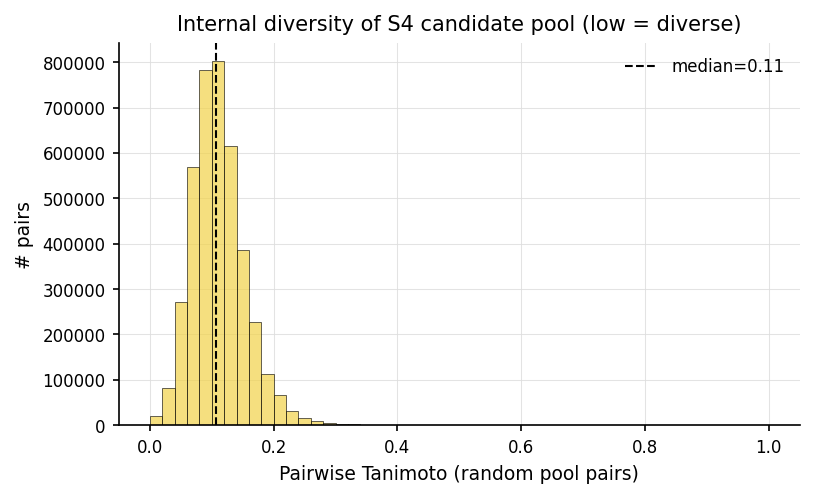

internal Tanimoto: median=0.106 mean=0.111 p10=0.061 p90=0.165


In [11]:
sample_a = buckets.sample(n=min(2000, len(buckets)), random_state=np.random.RandomState(0))
sample_b = buckets.sample(n=min(2000, len(buckets)), random_state=np.random.RandomState(1))
fps_a = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, nBits=2048) for s in sample_a['smiles']]
fps_b = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, nBits=2048) for s in sample_b['smiles']]
sims = np.asarray([BulkTanimotoSimilarity(q, fps_b) for q in fps_a]).flatten()
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.hist(sims, bins=np.linspace(0, 1, 51), color=POOL_COLOR, alpha=0.7, edgecolor='black', linewidth=0.4)
ax.axvline(np.median(sims), color='black', linestyle='--', linewidth=1, label=f'median={np.median(sims):.2f}')
ax.set_xlabel('Pairwise Tanimoto (random pool pairs)')
ax.set_ylabel('# pairs'); ax.set_title('Internal diversity of S4 candidate pool (low = diverse)')
ax.legend(frameon=False); _despine(ax); fig.tight_layout()
_save(fig, 'pool_internal_tanimoto'); plt.show()
print(f'internal Tanimoto: median={np.median(sims):.3f} mean={sims.mean():.3f} p10={np.percentile(sims,10):.3f} p90={np.percentile(sims,90):.3f}')

## 2a — Pool chemical-quality sanity (S4 pool only)

Sanity check on the pure-S4 pool — disconnected/charge/elements/heavy-atoms/MW.
The PubChem and Molpher tails are by construction valid PubChem chemistry /
formula-preserving morphs; their bulk shape is implicit in PubChem itself and
the query distribution.

In [12]:
POOL_QUALITY_N = 50_000
qual_sample = buckets.sample(n=min(POOL_QUALITY_N, len(buckets)), random_state=np.random.RandomState(0)).reset_index(drop=True)
n = len(qual_sample)
n_dot = int(qual_sample['smiles'].str.contains(r'\.').sum())

mols = qual_sample['smiles'].map(Chem.MolFromSmiles)
parse_ok = mols.notna()
mols_v = mols[parse_ok]
charges = mols_v.map(Chem.GetFormalCharge)
heavy = mols_v.map(lambda m: m.GetNumHeavyAtoms())
mw = mols_v.map(lambda m: rdMolDescriptors.CalcExactMolWt(m))

n_parse_fail = int((~parse_ok).sum())
n_charge_zero = int((charges == 0).sum())
n_charge_pos1 = int((charges == 1).sum())
n_charge_neg1 = int((charges == -1).sum())
n_charge_other = int(((charges != 0) & (charges != 1) & (charges != -1)).sum())

elements = Counter()
for m in mols_v:
    for atom in m.GetAtoms():
        elements[atom.GetSymbol()] += 1

print('=== S4 POOL CHEMICAL QUALITY SANITY ===')
print(f'  sampled rows: {n}')
print(f'  parses via RDKit: {n - n_parse_fail}')
print(f'  parse failures: {n_parse_fail}')
print(f'  disconnected ("."): {n_dot}  ({n_dot/n*100:.3f}%)')
print(f'  charge dist: 0={n_charge_zero}  +1={n_charge_pos1}  -1={n_charge_neg1}  other={n_charge_other}')
print(f'  unique elements: {len(elements)}')
print(f'  mean heavy atoms: {float(heavy.mean()):.2f}  median: {float(heavy.median()):.0f}  p90: {float(np.percentile(heavy, 90)):.0f}')
print(f'  mean MW: {float(mw.mean()):.1f} Da  median: {float(mw.median()):.1f} Da')
print()
print('Element histogram:')
for sym, cnt in elements.most_common(15):
    print(f'  {sym:>4}  {cnt:>10,}  ({cnt / sum(elements.values()) * 100:5.2f}%)')

=== S4 POOL CHEMICAL QUALITY SANITY ===
  sampled rows: 50000
  parses via RDKit: 50000
  parse failures: 0
  disconnected ("."): 0  (0.000%)
  charge dist: 0=49839  +1=116  -1=44  other=1
  unique elements: 9
  mean heavy atoms: 26.82  median: 26  p90: 36
  mean MW: 381.6 Da  median: 373.1 Da

Element histogram:
     C     992,985  (74.04%)
     O     180,862  (13.49%)
     N     124,594  ( 9.29%)
     S      15,442  ( 1.15%)
     F      12,657  ( 0.94%)
    Cl      10,788  ( 0.80%)
    Br       2,500  ( 0.19%)
     P         796  ( 0.06%)
     I         565  ( 0.04%)


## 3 — Per-formula and per-mass bucket-size distribution (final variants)

Now using the **final** S4+PC+Mol formula JSON and the final S4+PC mass JSON.

FINAL formula (S4+PC+Mol): n=28,918 median=1024 mean=682.8 p90=1024 max=1024 | trivial(len=1)=0 (0.00%) | len<8=0 (0.00%)
FINAL mass    (S4+PC)    : n=28,918 median=1024 mean=891.6 p90=1024 max=1024 | trivial(len=1)=0 (0.00%) | len<8=0 (0.00%)


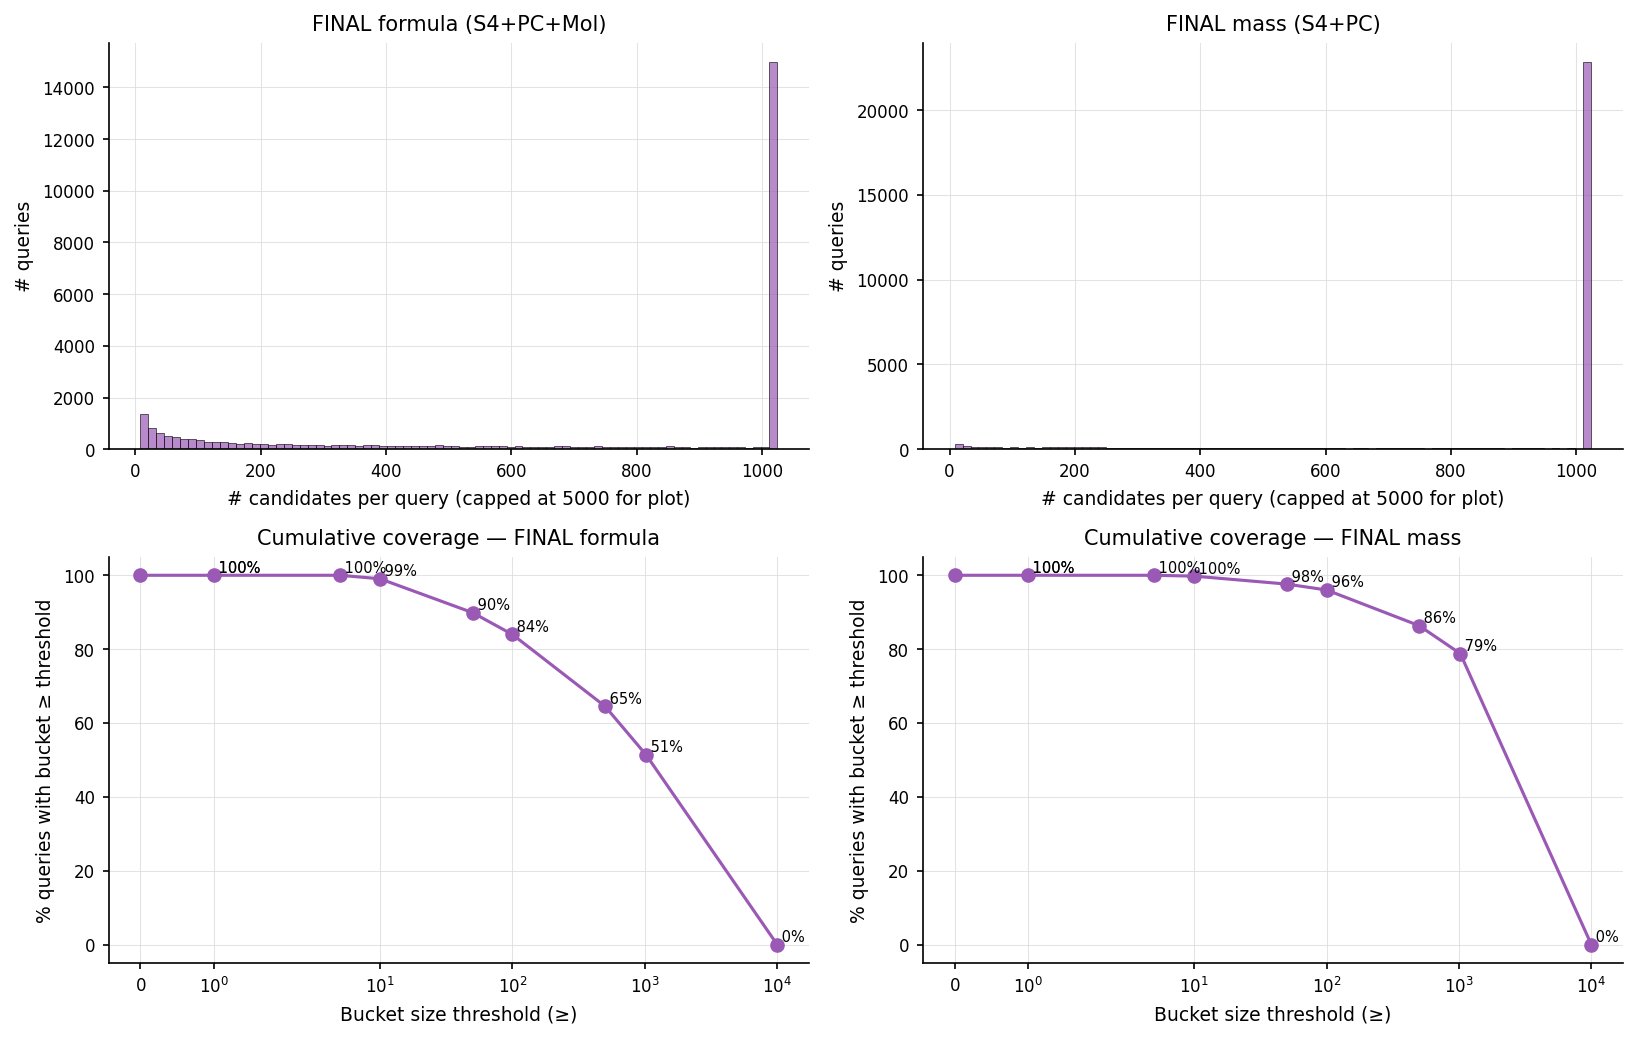

In [13]:
def _list_len_stats(d, label):
    L = np.asarray([len(v) for v in d.values()])
    n_trivial = int((L == 1).sum())
    n_lt8 = int((L < 8).sum())
    print(f'{label}: n={len(L):,} median={int(np.median(L))} mean={L.mean():.1f} p90={int(np.percentile(L,90))} max={int(L.max())} '
          f'| trivial(len=1)={n_trivial:,} ({n_trivial/len(L)*100:.2f}%) | len<8={n_lt8:,} ({n_lt8/len(L)*100:.2f}%)')
    return L

L_final_f = _list_len_stats(s4pcmol_f, 'FINAL formula (S4+PC+Mol)')
L_final_m = _list_len_stats(s4pc_m,    'FINAL mass    (S4+PC)    ')

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, L, label, color in zip(axes[0], [L_final_f, L_final_m], ['FINAL formula (S4+PC+Mol)', 'FINAL mass (S4+PC)'], [FINAL_COLOR, FINAL_COLOR]):
    ax.hist(np.clip(L, 0, 5000), bins=80, color=color, alpha=0.7, edgecolor='black', linewidth=0.4)
    ax.set_xlabel('# candidates per query (capped at 5000 for plot)')
    ax.set_ylabel('# queries'); ax.set_title(label)
    _despine(ax)
thresholds = [0, 1, 5, 10, 50, 100, 500, 1024, 10000]
for ax, L, label, color in zip(axes[1], [L_final_f, L_final_m], ['FINAL formula', 'FINAL mass'], [FINAL_COLOR, FINAL_COLOR]):
    covered = [(L >= t).mean() * 100 for t in thresholds]
    ax.plot(thresholds, covered, 'o-', color=color)
    ax.set_xscale('symlog'); ax.set_xlabel('Bucket size threshold (≥)')
    ax.set_ylabel('% queries with bucket ≥ threshold'); ax.set_title(f'Cumulative coverage — {label}')
    for t, p in zip(thresholds, covered):
        ax.text(max(t, 1), p, f' {p:.0f}%', fontsize=7, va='bottom')
    _despine(ax)
fig.tight_layout(); _save(fig, 'bucket_coverage_final'); plt.show()

## 3a — Qualitative examples: random queries → 4 candidates each (FORMULA final)

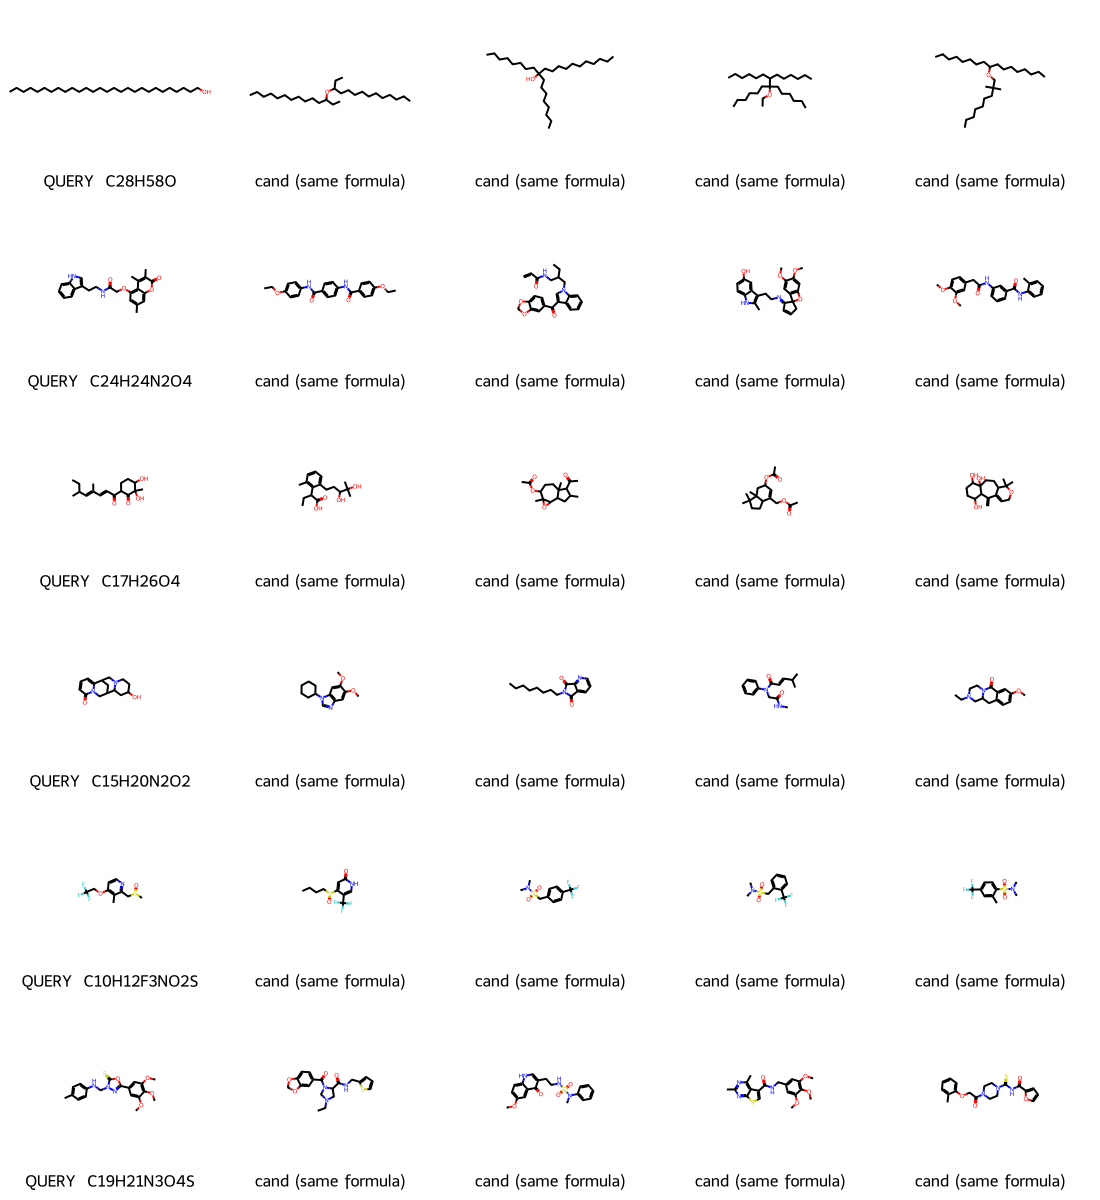

In [14]:
N_EX_QUERIES = 6; N_CAND_PER = 4
rng = np.random.RandomState(42)
ok_keys = [q for q in s4pcmol_f if len(s4pcmol_f[q]) >= N_CAND_PER + 1]
example_qs = list(rng.choice(ok_keys, size=min(N_EX_QUERIES, len(ok_keys)), replace=False))

mols_grid, legends = [], []
for q in example_qs:
    qm = Chem.MolFromSmiles(q)
    others = [c for c in s4pcmol_f[q][1:] if c != q]
    chosen = list(rng.choice(others, size=min(N_CAND_PER, len(others)), replace=False))
    cmols = [Chem.MolFromSmiles(c) for c in chosen]
    qf = rdMolDescriptors.CalcMolFormula(qm) if qm else '?'
    mols_grid.append(qm); legends.append(f'QUERY  {qf}')
    for cm in cmols:
        mols_grid.append(cm); legends.append('cand (same formula)')

img = MolsToGridImage(mols_grid, molsPerRow=N_CAND_PER + 1, subImgSize=(220, 200), legends=legends, returnPNG=True)
png_bytes = img.data if hasattr(img, 'data') else (img if isinstance(img, (bytes, bytearray)) else None)
if png_bytes:
    (FIG_DIR / 'qualitative_formula_final.png').write_bytes(png_bytes)
display(_IPImage(png_bytes) if png_bytes else img)

## 3b — Qualitative examples: random queries → 4 candidates each (MASS final)

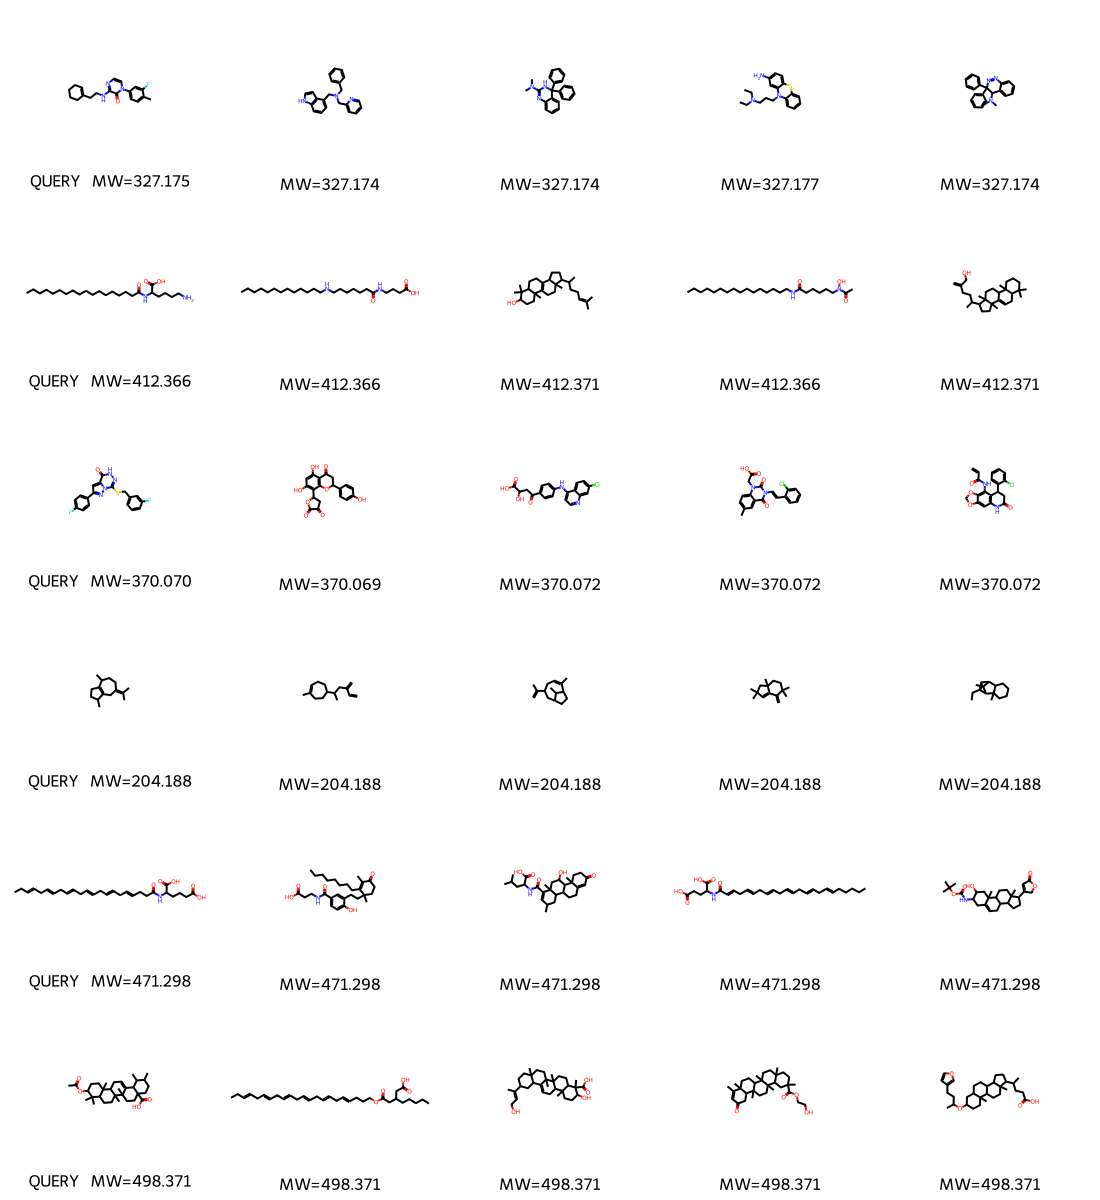

In [15]:
rng = np.random.RandomState(7)
ok_keys_m = [q for q in s4pc_m if len(s4pc_m[q]) >= N_CAND_PER + 1]
example_qs_m = list(rng.choice(ok_keys_m, size=min(N_EX_QUERIES, len(ok_keys_m)), replace=False))

mols_grid_m, legends_m = [], []
for q in example_qs_m:
    qm = Chem.MolFromSmiles(q)
    others = [c for c in s4pc_m[q][1:] if c != q]
    chosen = list(rng.choice(others, size=min(N_CAND_PER, len(others)), replace=False))
    cmols = [Chem.MolFromSmiles(c) for c in chosen]
    qmass = rdMolDescriptors.CalcExactMolWt(qm) if qm else 0.0
    mols_grid_m.append(qm); legends_m.append(f'QUERY  MW={qmass:.3f}')
    for cm in cmols:
        cmass = rdMolDescriptors.CalcExactMolWt(cm) if cm else 0.0
        mols_grid_m.append(cm); legends_m.append(f'MW={cmass:.3f}')

img_m = MolsToGridImage(mols_grid_m, molsPerRow=N_CAND_PER + 1, subImgSize=(220, 200), legends=legends_m, returnPNG=True)
png_bytes_m = img_m.data if hasattr(img_m, 'data') else (img_m if isinstance(img_m, (bytes, bytearray)) else None)
if png_bytes_m:
    (FIG_DIR / 'qualitative_mass_final.png').write_bytes(png_bytes_m)
display(_IPImage(png_bytes_m) if png_bytes_m else img_m)

## 4 — Tanimoto query → candidates (FORMULA final)

Per-query Tanimoto distribution of the final formula list against the query.

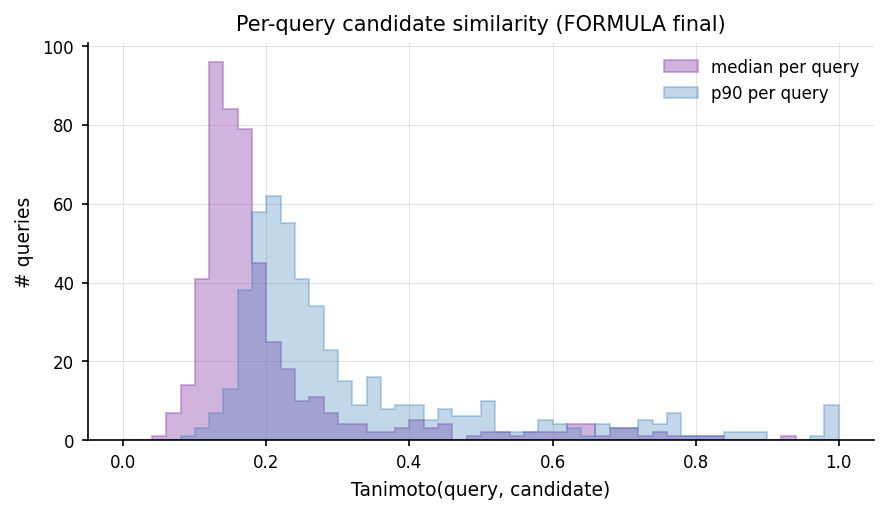

queries analysed: 500
median-Tanimoto: median=0.161 p10=0.117 p90=0.368


In [16]:
N_Q = 500; N_C_PER_Q = 200
rng = np.random.RandomState(0)
non_empty_keys = [q for q in s4pcmol_f if len(s4pcmol_f[q]) >= 2]
subset = rng.choice(non_empty_keys, size=min(N_Q, len(non_empty_keys)), replace=False)

med_per_q, p90_per_q = [], []
for q in subset:
    qm = Chem.MolFromSmiles(q)
    if qm is None: continue
    qfp = AllChem.GetMorganFingerprintAsBitVect(qm, 2, nBits=2048)
    cands = s4pcmol_f[q][1:]
    if len(cands) > N_C_PER_Q:
        cands = list(rng.choice(cands, size=N_C_PER_Q, replace=False))
    cfps = []
    for s in cands:
        m = Chem.MolFromSmiles(s)
        if m is not None:
            cfps.append(AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048))
    if not cfps: continue
    s = np.asarray(BulkTanimotoSimilarity(qfp, cfps))
    med_per_q.append(float(np.median(s)))
    p90_per_q.append(float(np.percentile(s, 90)))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(med_per_q, bins=np.linspace(0, 1, 51), histtype='stepfilled', alpha=0.45, color=FINAL_COLOR, edgecolor=FINAL_COLOR, label='median per query')
ax.hist(p90_per_q, bins=np.linspace(0, 1, 51), histtype='stepfilled', alpha=0.30, color='#377EB8', edgecolor='#377EB8', label='p90 per query')
ax.set_xlabel('Tanimoto(query, candidate)'); ax.set_ylabel('# queries')
ax.set_title('Per-query candidate similarity (FORMULA final)')
ax.legend(frameon=False); _despine(ax); fig.tight_layout()
_save(fig, 'tanimoto_query_to_candidates_formula_final'); plt.show()
print(f'queries analysed: {len(med_per_q):,}')
print(f'median-Tanimoto: median={np.median(med_per_q):.3f} p10={np.percentile(med_per_q,10):.3f} p90={np.percentile(med_per_q,90):.3f}')

## 5 — Side-by-side comparison vs PubChem v1.5 (baseline)

,n_entries,median_len,mean_len,p90_len,max_len,trivial (len=1),trivial_pct
name,,,,,,,
"FINAL formula (S4+PC+Mol, 1024-cap)",28918,1024,682.823051,1024,1024,0,0.0
PubChem v1.5 formula (256-cap),32010,256,212.060856,256,256,128,0.4
"FINAL mass (S4+PC, ±10ppm, 1024-cap)",28918,1024,891.600007,1024,1024,0,0.0
"PubChem v1.5 mass (±10ppm, 256-cap)",32010,256,252.845954,256,256,0,0.0


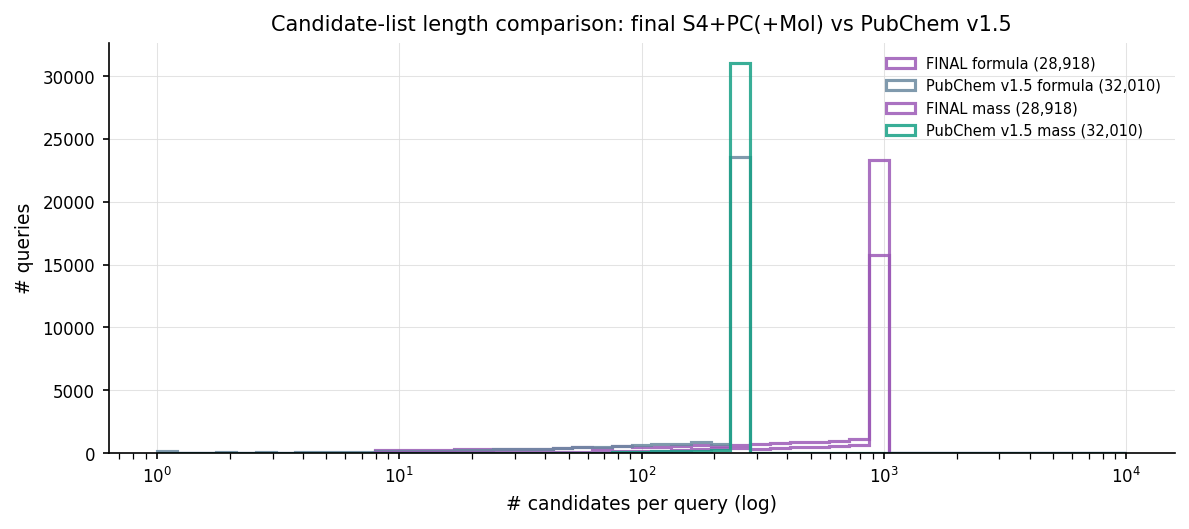

In [17]:
with PUBCHEM_F_V15_JSON.open() as f: pcv15_f = json.load(f)
with PUBCHEM_M_V15_JSON.open() as f: pcv15_m = json.load(f)

def _stats(d, label):
    L = np.asarray([len(v) for v in d.values()])
    n1 = int((L == 1).sum())
    return {
        'name': label, 'n_entries': len(d),
        'median_len': int(np.median(L)), 'mean_len': float(L.mean()),
        'p90_len': int(np.percentile(L, 90)), 'max_len': int(L.max()),
        'trivial (len=1)': n1, 'trivial_pct': round(n1 / len(L) * 100, 3),
    }
df_cmp = pd.DataFrame([
    _stats(s4pcmol_f, 'FINAL formula (S4+PC+Mol, 1024-cap)'),
    _stats(pcv15_f,   'PubChem v1.5 formula (256-cap)'),
    _stats(s4pc_m,    'FINAL mass (S4+PC, ±10ppm, 1024-cap)'),
    _stats(pcv15_m,   'PubChem v1.5 mass (±10ppm, 256-cap)'),
]).set_index('name')
display(df_cmp)

fig, ax = plt.subplots(figsize=(8, 3.6))
bins = np.logspace(0, 4, 50)
for L, color, label in [
    (np.asarray([len(v) for v in s4pcmol_f.values()]), FINAL_COLOR, f'FINAL formula ({len(s4pcmol_f):,})'),
    (np.asarray([len(v) for v in pcv15_f.values()]),   PUBCHEM_COLOR, f'PubChem v1.5 formula ({len(pcv15_f):,})'),
    (np.asarray([len(v) for v in s4pc_m.values()]),    '#9B59B6', f'FINAL mass ({len(s4pc_m):,})'),
    (np.asarray([len(v) for v in pcv15_m.values()]),   '#16A085', f'PubChem v1.5 mass ({len(pcv15_m):,})'),
]:
    ax.hist(L, bins=bins, histtype='step', linewidth=1.5, alpha=0.85, color=color, label=label)
ax.set_xscale('log')
ax.set_xlabel('# candidates per query (log)'); ax.set_ylabel('# queries')
ax.set_title('Candidate-list length comparison: final S4+PC(+Mol) vs PubChem v1.5')
ax.legend(frameon=False, fontsize=7); _despine(ax)
fig.tight_layout(); _save(fig, 'list_length_compare_final'); plt.show()

## 5a — Queries with zero or few candidates

After all augmentation steps, there should be **no** queries with len<8 in either variant.

In [18]:
def _zero_few_summary(d, label):
    L = np.asarray([len(v) for v in d.values()])
    print(f'{label}:')
    print(f'  trivial (len=1): {int((L == 1).sum()):,} ({(L == 1).mean()*100:.3f}%)')
    print(f'  len<8:           {int((L < 8).sum()):,} ({(L < 8).mean()*100:.3f}%)')
    print(f'  len<20:          {int((L < 20).sum()):,} ({(L < 20).mean()*100:.3f}%)')

_zero_few_summary(s4pcmol_f, 'FINAL formula')
_zero_few_summary(s4pc_m,    'FINAL mass')

FINAL formula:
  trivial (len=1): 0 (0.000%)
  len<8:           0 (0.000%)
  len<20:          1,275 (4.409%)
FINAL mass:
  trivial (len=1): 0 (0.000%)
  len<8:           0 (0.000%)
  len<20:          315 (1.089%)


## 6 — Sanity checks (formula + mass consistency)

In [19]:
rng = np.random.RandomState(0)

# Formula spot-check.
sample_keys = rng.choice(list(s4pcmol_f.keys()), size=500, replace=False)
n_match_f = n_total_f = 0
n_misordered = 0
for q in sample_keys:
    cands = s4pcmol_f[q]
    if cands[0] != q:
        n_misordered += 1; continue
    qm = Chem.MolFromSmiles(q)
    if qm is None: continue
    qf = rdMolDescriptors.CalcMolFormula(qm)
    for c in cands[1:][:50]:
        cm = Chem.MolFromSmiles(c)
        if cm is None: continue
        n_total_f += 1
        if rdMolDescriptors.CalcMolFormula(cm) == qf:
            n_match_f += 1

# Mass spot-check.
sample_keys_m = rng.choice(list(s4pc_m.keys()), size=500, replace=False)
n_match_m = n_total_m = 0
PPM = 10
for q in sample_keys_m:
    cands = s4pc_m[q]
    qm = Chem.MolFromSmiles(q)
    if qm is None: continue
    q_mass = rdMolDescriptors.CalcExactMolWt(qm)
    tol = q_mass * PPM * 1e-6
    for c in cands[1:][:50]:
        cm = Chem.MolFromSmiles(c)
        if cm is None: continue
        n_total_m += 1
        if abs(rdMolDescriptors.CalcExactMolWt(cm) - q_mass) <= tol:
            n_match_m += 1

print(f'FORMULA spot-check — query-at-index-0: {500-n_misordered}/500')
print(f'FORMULA spot-check — match: {n_match_f:,}/{n_total_f:,} = {n_match_f/max(n_total_f,1)*100:.2f}%')
print(f'MASS spot-check    — match (±{PPM} ppm): {n_match_m:,}/{n_total_m:,} = {n_match_m/max(n_total_m,1)*100:.2f}%')

FORMULA spot-check — query-at-index-0: 500/500
FORMULA spot-check — match: 23,615/23,615 = 100.00%
MASS spot-check    — match (±10 ppm): 24,760/24,760 = 100.00%


## 6a — Per-bucket 2D-InChIKey uniqueness sanity

In [20]:
N_BUCKETS = 100; MAX_PER_BUCKET = 500
rng = np.random.RandomState(0)

def _check_unique(d, label):
    non_trivial = [q for q in d if len(d[q]) >= 2]
    samp = list(rng.choice(non_trivial, size=min(N_BUCKETS, len(non_trivial)), replace=False))
    n_dup = 0
    for q in samp:
        cands = d[q]
        if len(cands) > MAX_PER_BUCKET + 1:
            cands = [cands[0]] + list(rng.choice(cands[1:], size=MAX_PER_BUCKET, replace=False))
        iks = []
        for s in cands:
            m = Chem.MolFromSmiles(s)
            if m is None: continue
            try: iks.append(Chem.MolToInchiKey(m)[:14])
            except Exception: pass
        if iks and len(iks) != len(set(iks)):
            n_dup += 1
    print(f'{label}: buckets checked={len(samp)}, with InChIKey duplicates={n_dup}')

_check_unique(s4pcmol_f, 'FINAL formula (S4+PC+Mol)')
_check_unique(s4pc_m,    'FINAL mass (S4+PC)')

FINAL formula (S4+PC+Mol): buckets checked=100, with InChIKey duplicates=3


FINAL mass (S4+PC): buckets checked=100, with InChIKey duplicates=2


## 7 — Summary table

In [21]:
summary = {
    'MSG queries (all folds)': len(queries),
    'S4 pool size (post canon + dedup)': n_pool,
    'unique formulas in S4 pool': int(buckets['formula'].nunique()),
    'pool overlap with MSG-train': int(buckets['inchikey_2d'].isin(msg_iks_train).sum()),
    'pool overlap with MSG val+test': int(buckets['inchikey_2d'].isin(msg_iks_valtest).sum()),
    'FORMULA final — n_queries': len(s4pcmol_f),
    'FORMULA final — trivial (len=1)': int((np.asarray([len(v) for v in s4pcmol_f.values()]) == 1).sum()),
    'FORMULA final — len<8': int((np.asarray([len(v) for v in s4pcmol_f.values()]) < 8).sum()),
    'FORMULA final — total S4 cands': int(df_attr_f['n_s4'].sum()),
    'FORMULA final — total PubChem cands': int(df_attr_f['n_pc'].sum()),
    'FORMULA final — total Molpher cands': int(df_attr_f['n_mol'].sum()),
    'MASS final — n_queries': len(s4pc_m),
    'MASS final — trivial (len=1)': int((np.asarray([len(v) for v in s4pc_m.values()]) == 1).sum()),
    'MASS final — len<8': int((np.asarray([len(v) for v in s4pc_m.values()]) < 8).sum()),
    'MASS final — total S4 cands': int(df_attr_m['n_s4'].sum()),
    'MASS final — total PubChem cands': int(df_attr_m['n_pc'].sum()),
}
display(pd.DataFrame([summary]).T.rename(columns={0: 'value'}))

,value
MSG queries (all folds),28918
S4 pool size (post canon + dedup),64205194
unique formulas in S4 pool,1470580
pool overlap with MSG-train,13258
pool overlap with MSG val+test,144
FORMULA final — n_queries,28918
FORMULA final — trivial (len=1),0
FORMULA final — len<8,0
FORMULA final — total S4 cands,19348920
FORMULA final — total PubChem cands,42789
